По базе машин с ЮЛЫ данным обучите модель для предсказания цен на машины.

1. Создайте обучающую, тестовую и проверочную выборки.

2. Оцените качество работы созданной сети, определив средний процент ошибки на проверочной выборке. (Для этого потребуется привести предсказанные моделью значения к первоначальному диапазону цен.)  

3. Подсчитайте ошибку на каждом примере тестовой выборки и суммарный процент ошибки.


Рекомендации:
- в качестве ошибки рекомендуется использовать среднеквадратическую ошибку (mse).
- метрику для данной задачи можно не использовать.
- последний слой модели должен иметь 1 нейрон.
- суммарный процент ошибки = средний модуль ошибки (MAE) / среднюю цену машины. Например, если средняя цена машины 560.000 р, а средняя ошибка 56.000р, то процент ошибки равен 10%.


In [ ]:
# Загрузка датафрейма из google облака
import gdown

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/cars_new.csv', None, quiet=True)

'cars_new.csv'

,mark,model,price,year,mileage,body,kpp,fuel,volume,power
0,kia,cerato,996000,2018,28000,седан,автомат,бензин,2.0,150.0
1,daewoo,nexia 1 поколение [2-й рестайлинг],140200,2012,60500,седан,механика,бензин,1.5,80.0
2,suzuki,jimny 3 поколение [рестайлинг],750000,2011,29000,внедорожник,автомат,бензин,1.3,85.0
3,bmw,x1 18 e84 [рестайлинг],970000,2014,49500,кроссовер,автомат,бензин,2.0,150.0
4,chevrolet,lacetti 1 поколение,205000,2007,151445,седан,механика,бензин,1.4,95.0


(70119, 10)
Index(['mark', 'model', 'price', 'year', 'mileage', 'body', 'kpp', 'fuel',
       'volume', 'power'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5004эпоха: 1 mae: 125134.93 руб. ошибка: 23.59 %
767/767 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - loss: 0.4176 - val_loss: 0.2758
Epoch 2/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2421эпоха: 2 mae: 108981.61 руб. ошибка: 20.55 %
767/767 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - loss: 0.2367 - val_loss: 0.2314
Epoch 3/100
766/767 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1969эпоха: 3 mae: 97720.93 руб. ошибка: 18.42 %
767/767 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - loss: 0.1731 - val_loss: 0.1371
Epoch 4/100
766/767 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1317эпоха: 4 mae: 98439.37 руб. ошибка: 18.56 %
767/767 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - loss: 0.1380 - val_loss: 0.2032
Epoch 5/100
766/767 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1347эпоха: 5 mae: 92805.51 руб. ошибка: 17.5 %
767/767 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - loss: 0.1595 - val_loss: 0.1348
Epoch 6/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step 

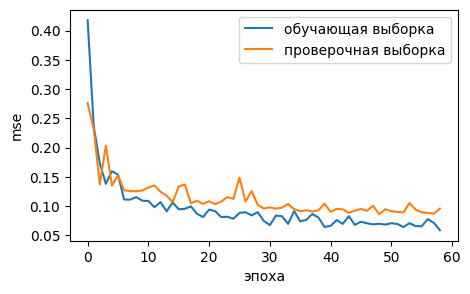

329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
ошибка на проверочной выборке
MAE: 73362.34 руб.
MSE: 33372160000.0
средний процент ошибки: 13.83 %
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


,реальная цена,предсказанная цена,ошибка,"ошибка, %"
0,275000.0,3.438573e+05,68857.34375,25.039036
1,500000.0,5.125572e+05,12557.15625,2.511431
2,1195000.0,1.166687e+06,28313.00000,2.369289
3,290000.0,3.016516e+05,11651.59375,4.017791
4,135000.0,1.208411e+05,14158.90625,10.488079
...,...,...,...,...
10512,270000.0,3.671329e+05,97132.90625,35.975151
10513,360000.0,3.309782e+05,29021.75000,8.061598
10514,110000.0,1.197428e+05,9742.78125,8.857074
10515,140000.0,1.316217e+05,8378.31250,5.984509


ошибка на тестовой выборке
MAE: 77384.06 руб.
MSE: 84605616128.0
суммарный процент ошибки: 14.4 %


In [ ]:
# Ваше решение
# импортирование библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LambdaCallback
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# загрузка базы
df = pd.read_csv('cars_new.csv')

# просмотр базы
display(df.head())
print(df.shape)
print(df.columns)

# определение столбца цены
price_columns = [col for col in df.columns if str(col).lower() in ['price', 'цена']]
price_col = price_columns[0]

# очистка цены
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

# удаление пустых значений
df = df.dropna()

# формирование признаков и целевого значения
y = df[price_col].values
x = df.drop(price_col, axis=1)

# преобразование числовых строк в числа
for col in x.columns:
    converted = pd.to_numeric(x[col], errors='coerce')
    if converted.notna().mean() > 0.9:
        x[col] = converted

# преобразование категориальных признаков
x = pd.get_dummies(x)

# преобразование типов
x = x.astype('float32')
y = y.astype('float32')

# разделение на обучающую и временную выборки
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)

# разделение временной выборки на проверочную и тестовую
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

# масштабирование признаков
scaler_x = StandardScaler()
x_train = scaler_x.fit_transform(x_train)
x_val = scaler_x.transform(x_val)
x_test = scaler_x.transform(x_test)

# масштабирование цены
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))

# создание модели
model = Sequential([Dense(512, input_shape=(x_train.shape[1],)), BatchNormalization(), Activation('relu'), Dropout(0.2), Dense(256), BatchNormalization(), Activation('relu'), Dropout(0.2), Dense(128, activation='relu'), Dense(64, activation='relu'), Dense(1, activation='linear')])

# компиляция модели
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# вывод ошибки после каждой эпохи
def on_epoch_end(epoch, logs):
    pred = model.predict(x_val, verbose=0)
    pred = scaler_y.inverse_transform(pred).flatten()
    mae = mean_absolute_error(y_val, pred)
    percent = mae / np.mean(y_val) * 100
    print('эпоха:', epoch + 1, 'mae:', round(mae, 2), 'руб.', 'ошибка:', round(percent, 2), '%')

# создание callbacks
pltMae = LambdaCallback(on_epoch_end=on_epoch_end)
stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# обучение модели
history = model.fit(x_train, y_train_scaled, validation_data=(x_val, y_val_scaled), epochs=100, batch_size=64, callbacks=[pltMae, stop], verbose=1)

# построение графика ошибки
plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'], label='обучающая выборка')
plt.plot(history.history['val_loss'], label='проверочная выборка')
plt.xlabel('эпоха')
plt.ylabel('mse')
plt.legend()
plt.show()

# предсказание на проверочной выборке
pred_val_scaled = model.predict(x_val)
pred_val = scaler_y.inverse_transform(pred_val_scaled).flatten()

# расчет ошибки на проверочной выборке
mae_val = mean_absolute_error(y_val, pred_val)
mse_val = mean_squared_error(y_val, pred_val)
percent_val = mae_val / np.mean(y_val) * 100

print('ошибка на проверочной выборке')
print('MAE:', round(mae_val, 2), 'руб.')
print('MSE:', round(mse_val, 2))
print('средний процент ошибки:', round(percent_val, 2), '%')

# предсказание на тестовой выборке
pred_test_scaled = model.predict(x_test)
pred_test = scaler_y.inverse_transform(pred_test_scaled).flatten()

# расчет ошибки на каждом примере тестовой выборки
errors = np.abs(y_test - pred_test)
percent_errors = errors / y_test * 100

# формирование таблицы ошибок
test_result = pd.DataFrame({'реальная цена': y_test, 'предсказанная цена': pred_test, 'ошибка': errors, 'ошибка, %': percent_errors})

display(test_result)

# расчет суммарной ошибки на тестовой выборке
mae_test = mean_absolute_error(y_test, pred_test)
mse_test = mean_squared_error(y_test, pred_test)
percent_test = mae_test / np.mean(y_test) * 100

print('ошибка на тестовой выборке')
print('MAE:', round(mae_test, 2), 'руб.')
print('MSE:', round(mse_test, 2))
print('суммарный процент ошибки:', round(percent_test, 2), '%')